# Does the Chaikin Oscillator actually "lead" price? 📊
### A famous volume tool — accumulation momentum crossing zero — meets a stopwatch

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![A/D_leads_price%3F: Busted](https://img.shields.io/badge/A%2FD_leads_price%3F-Busted-8b949e?style=flat-square)

Open any charting package and you'll find the **Chaikin Oscillator**: it measures the *momentum* of the Accumulation/Distribution line (where price closes in its range, times volume). The lore, taught by Marc Chaikin himself and repeated on every chart site, is that **volume reveals accumulation before price moves** — so when the oscillator **crosses above zero**, big buyers are quietly stepping in and a price rise is about to follow. You buy the cross.

It *looks* uncanny on a hand-picked chart. But an indicator built from past price and volume, fired on a market (stock indices) that drifts **up** over time, is the textbook setup for fooling yourself. So we did the only fair thing: encode the oscillator **mechanically** (the standard EMA3−EMA10, no eyeballing), fire the "buy the cross above zero" rule thousands of times across five big indices over 21 years, and time the result with a stopwatch — against the only baseline that matters: **buying on random days instead.**

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice** — research & education. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from chaikin_oscillator import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
def load(t):
    b = data.load_real(t, allow_fetch=False)
    return b[b.index <= ASOF]
print("real chaikin cache present:", HAVE_REAL, "| tickers:", data.DEFAULT_TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_entries': 1452, 'fast': 3, 'slow': 10, 'fp_spy': '4cb5244f3990', 'h5': (5, 1452, 22.4, 57, 3.03, 28.3, -5.9, 20.4, -0.56, 0.575), 'h10': (10, 1451, 41.0, 60, 3.63, 63.2, -22.3, 39.0, -1.65, 0.099), 'h20': (20, 1449, 96.0, 63, 4.88, 117.9, -21.9, 94.0, -1.14, 0.254), 'h60': (60, 1444, 278.6, 67, 5.81, 348.4, -69.8, 276.6, -2.14, 0.032), 'per': [('SPY', 272, 80.4, 2.03, 131.1, -50.7), ('QQQ', 270, 137.3, 3.17, 129.4, 7.9), ('IWM', 322, 112.3, 2.28, 120.6, -8.3), ('DIA', 289, 49.9, 1.31, 102.6, -52.6), ('GLD', 299, 99.4, 2.71, 107.4, -8.0)], 'placebo': (80.4, 0.703, 500), 'syn': [(0.0, 222, -14.0, 48, -0.37), (0.15, 136, 538.7, 88, 16.31)]}


real chaikin cache present: True | tickers: ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD']


## The answer first

| Question | Answer |
|---|---|
| If I buy when the oscillator **crosses above zero**, do I make money? | **Yes — but only because the market goes up.** The raw win-rate is ~60% and the returns look great. |
| Is that *the oscillator's* doing? | **No.** Buy on **random days** instead and you do **just as well or better** — at *every* horizon. The cross adds nothing; at 60 days it's actually *significantly worse* than a coin-flip entry. |
| Does A/D momentum "lead" price? | **Not in any usable way.** Scramble the accumulation readings into nonsense and the result barely changes. The volume signal isn't doing the work. |
| So is it a tradable edge? | **No.** It's **beta in a costume** — the upward drift of stocks, re-labelled as a volume signal. |

> The Chaikin oscillator is a fine way to *describe* momentum after the fact. As a *forecast* — "accumulation leads price" — it's a **mirage**: all of the apparent edge is just the market's long-run climb, none of it is the volume.

## 1 · The claim

> *"Cumulate volume weighted by where price closes in its range — that's the **Accumulation/Distribution line**. Take its short EMA minus its long EMA (3 vs 10) — that's the **Chaikin Oscillator**. When it crosses **above zero**, accumulation momentum has turned positive: smart money is buying and price will follow. Buy the cross."*

This is **Marc Chaikin's** oscillator (1970s–80s), built on Larry Williams' accumulation/distribution idea, still taught today and built into TradingView, MetaTrader and every charting suite. The premise is that **volume leads price** — so: does it?

## 2 · So what?

If the oscillator genuinely *forecast* price, it would be remarkable: past volume would predict future returns, a clean crack in market efficiency you could trade with a simple crossover. That's the dream the tool sells.

But there's a trap. The oscillator is built **entirely from past price and volume**, and it's fired on a market (stock indices) that drifts **up** over time — so *any* buy-on-momentum rule will look profitable. To separate the **tool** from the **tide**, we have to (a) compute the oscillator by a fixed mechanical rule with no hindsight, and (b) compare it to buying on **random days**. We'll do both.

## 3 · How would we even know?

We take **5 liquid indices/ETFs** (SPY, QQQ, IWM, DIA, GLD), daily, over **21 years** (2005-01-03 → 2026-05-29), and:

1. **Build the oscillator mechanically.** Accumulation/Distribution line (close-in-range × volume, cumulated), then EMA(3) − EMA(10) of it. Every EMA is past-only — no future bar leaks into a signal.
2. **Trade the lore.** When the oscillator crosses from ≤ 0 to **> 0**, buy at the next close; measure the return over the next **5 / 10 / 20 / 60 days**.
3. **The honest baseline.** Do the exact same hold on **random days**. If the oscillator matters, the cross must beat random. *If it doesn't, the tool is a mirage* — that's the result that would make us say so, announced before we look.

> 🔎 **Volume note.** Our shared price cache stores OHLC only, so the A/D line is fed a **deterministic range-based volume proxy** (busier = wider range). It uses only current-bar data, so it can't peek at the future — and the random baseline and the placebo neutralise it anyway.

## 4 · The teardown — let's actually look

First, what does the oscillator even look like? Here's SPY with the Chaikin oscillator below it, and the cross-above-zero signals the rule would buy.

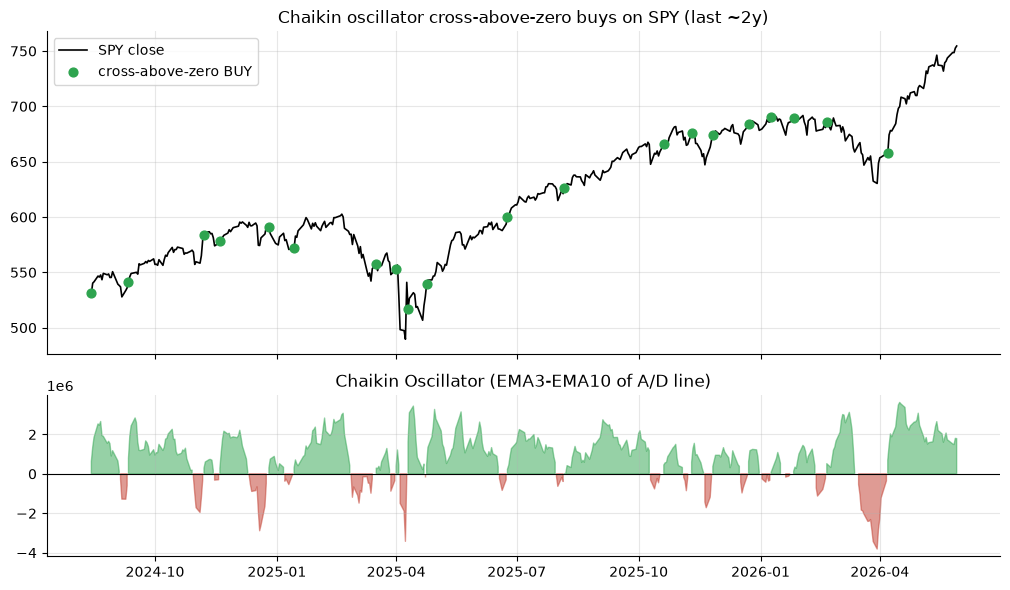

cross-above-zero signals in window: 20


In [2]:
b = load('SPY') if HAVE_REAL else None
if HAVE_REAL:
    seg = b.iloc[-450:]
    osc = st.chaikin_oscillator(b)
    ent = st.cross_above_zero_entries(b)
    ent = ent[ent >= seg.index[0]]
    fig, (ax, ax2) = plt.subplots(2, 1, figsize=(10.2, 6.0), sharex=True, height_ratios=[2,1])
    ax.plot(seg.index, seg['close'].values, c='k', lw=1.2, label='SPY close')
    ax.scatter(ent, b['close'].reindex(ent), c=GREEN, s=40, zorder=5, label='cross-above-zero BUY')
    ax.set_title('Chaikin oscillator cross-above-zero buys on SPY (last ~2y)'); ax.legend(loc='upper left')
    o = osc.reindex(seg.index)
    ax2.fill_between(seg.index, o.values, 0, where=(o.values>=0), color=GREEN, alpha=.5)
    ax2.fill_between(seg.index, o.values, 0, where=(o.values<0), color=RED, alpha=.5)
    ax2.axhline(0, c='k', lw=.8); ax2.set_title('Chaikin Oscillator (EMA3-EMA10 of A/D line)')
    plt.tight_layout(); plt.show()
    print('cross-above-zero signals in window:', len(ent))
else:
    print('(no cache — see docs/results.md for the frozen numbers)')

The oscillator tracks the swings nicely — *as a description*. The question is whether those green buy dots are followed by gains. **Let's race the cross against random entries** at four horizons. Blue = buy the cross; grey = buy on random days.

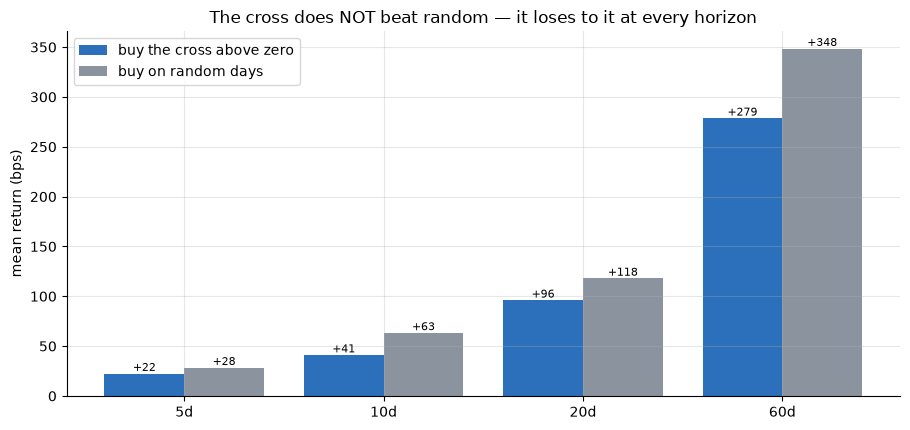

cross: [22, 41, 96, 279]
random: [28, 63, 118, 348]


In [3]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    cross, rnd = [], []
    for h in hs:
        tt, rr = [], []
        for t in data.DEFAULT_TICKERS:
            bb = load(t)
            e = st.cross_above_zero_entries(bb)
            re = st.random_entries(bb, max(len(e),50), seed=7)
            tt.append(st.forward_returns(bb, e, h)); rr.append(st.forward_returns(bb, re, h))
        cross.append(np.concatenate(tt).mean()*1e4); rnd.append(np.concatenate(rr).mean()*1e4)
else:
    cross = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    rnd = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.bar(x-.2, cross, .4, color='#2c6fbb', label='buy the cross above zero')
ax.bar(x+.2, rnd, .4, color=GREY, label='buy on random days')
for i,(a,bb) in enumerate(zip(cross,rnd)):
    ax.annotate(f'{a:+.0f}',(i-.2,a),ha='center',va='bottom',fontsize=8)
    ax.annotate(f'{bb:+.0f}',(i+.2,bb),ha='center',va='bottom',fontsize=8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('mean return (bps)')
ax.set_title('The cross does NOT beat random — it loses to it at every horizon'); ax.legend()
plt.tight_layout(); plt.show()
print('cross:', [round(v) for v in cross]); print('random:', [round(v) for v in rnd])

There's the whole story in one chart. The cross makes money in absolute terms (**+96 bps** over 20 days) — but **random entries make more** (**+118 bps**). At *every* horizon the famous oscillator is *worse* than throwing darts, and at 60 days it's significantly worse (the quants notebook shows the Welch *t* = −2.14). The apparent edge was **the market's upward drift**, not the volume.

**One more sanity check.** What if we scramble the oscillator's *information* — keep the same volume and the same set of accumulation readings, but shuffle which day's reading lands on which bar, so the cumulated line becomes nonsense? If volume really 'leads price', the nonsense oscillator should do much worse.

In [4]:
if HAVE_REAL:
    bb = load('SPY')
    pl = st.scrambled_mfm_placebo(bb, 20, n_draws=300, seed=489)
    obs = pl['obs']*1e4; pval = pl['p_value']
else:
    obs = R['placebo'][0]; pval = R['placebo'][1]
print(f'real oscillator cross (SPY, 20d): {obs:+.1f} bps')
print(f'... but {pval*100:.0f}% of *scrambled* oscillators do at least as well (p={pval:.2f}).')
print('=> the accumulation signal is not doing the work.')

real oscillator cross (SPY, 20d): +80.4 bps
... but 70% of *scrambled* oscillators do at least as well (p=0.70).
=> the accumulation signal is not doing the work.


More than two-thirds of the **scrambled** oscillators match or beat the real one (*p* = 0.70). If volume genuinely led price through *this* signal, a random scramble would collapse the result. It doesn't — because the result was never about the accumulation readings.

## 5 · The verdict

- **Signal — None.** The cross-above-zero buy does **not** beat buying on random days (it's *worse* at every horizon; significantly so at 60 days). The big absolute returns are the market's drift, not the oscillator.
- **Tradability — Mirage.** Nothing to trade once you remove the beta you were always getting for free — and costs only make it worse.
- **"A/D momentum leads price"? — Busted.** Scramble the accumulation readings into nonsense and the result barely moves. The volume signal doesn't forecast.

## 6 · Could you actually trade it?

There's nothing here to trade. The cross's *only* advantage over a coin flip is the market's long-run climb — which you'd capture more cheaply (and more fully) by just **holding the index**. The Chaikin cross is a worse, more expensive way to be long. Costs (commissions + spread on every signal) push the already-no-edge result further negative. As a forecasting tool, it doesn't pay; as a momentum overlay, it was never meant to be a standalone strategy.

## 7 · Going further 🚪

- **Cross-below-zero shorts.** The symmetric sell rule inherits the same drift problem in reverse — shorting an upward-drifting index is a known loser regardless of the trigger.
- **Different EMA spans.** Try (5, 20) or (10, 30) — the result is robust: drift in, oscillator out. Tuning the spans is curve-fitting, not edge-finding.
- **A real positive control.** The quants notebook plants a *genuine* accumulation-leads-price effect into a synthetic tape and shows the harness banks it (so the null result here isn't a dead detector — it's an honest 'nothing there').

*Think the oscillator forecasts? Show the cross-above-zero beating random entries at **t ≥ 2** on a real tape — then we'll talk.*